Metodologia porównania wzorowana na *Gonçalves et al. „Comparing and combining sentiment analysis methods" (COSN 2013)*:
- **Prediction Performance** — Precision, Recall, F1, Accuracy *(cf. Table 5)*
- **F1 per aspekt** — skuteczność per aspekt *(cf. Table 6)*
- **Agreement** — zgodność między metodami *(cf. Table 4)*
- **Coverage** — odsetek aktywnych predykcji *(cf. Figure 1, 4)*
- **Macierze pomyłek** — rozkład błędów per klasa

In [6]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score,
)
from pathlib import Path

from config.global_config import TRAIN_ASPECTS, SENTIMENT_LABELS, ModelType
from predictions.predict_dataset import predict_dataset

ASPECTS = TRAIN_ASPECTS

CACHE_DIR = Path("statics/prediction_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
TEST_PATH = "statics/datasets/validate.csv"

plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 11, "font.size": 9})

def flat(df):
    """Spłaszcza aspekty z DataFrame do jednego wektora etykiet."""
    return np.concatenate([df[a].values for a in ASPECTS])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
df = pd.read_csv(TEST_PATH)
for a in ASPECTS:
    df[a] = df[a].fillna("notmentioned")

gt = df[["text"] + ASPECTS].copy()
print(f"Zbiór: {len(gt)} recenzji × {len(ASPECTS)} aspektów = {len(gt) * len(ASPECTS)} etykiet\n")
gt[ASPECTS].apply(pd.Series.value_counts).T.fillna(0).astype(int).reindex(columns=SENTIMENT_LABELS)

Zbiór: 84 recenzji × 8 aspektów = 672 etykiet



,positive,neutral,negative,notmentioned
safety,18,4,9,53
cleanliness,5,0,4,75
infrastructure,19,9,7,49
nature,6,1,0,77
attractions,16,2,1,65
heritage,3,4,0,77
costs,13,4,5,62
other,43,7,10,24


In [8]:

from tqdm import tqdm
import os
import pandas as pd
from typing import Callable


type should_use_cache = bool
type Method = tuple[ModelType, should_use_cache]

USE_CACHE = True

METHODS: dict[str, Method] = {
    "Fine-tuned DISTILBERT": (ModelType.FINE_TUNED_DISTILBERT, USE_CACHE),
    "Fine-tuned BERT": (ModelType.FINE_TUNED_BERT, USE_CACHE),
}



def handle_progress(model_name: str):
    pbar = None

    def update_callback(progress, total):
        nonlocal pbar
        
        if pbar is None:
            pbar = tqdm(total=total, desc=f"[{model_name}]", unit="it")
        
        pbar.n = progress
        pbar.refresh()

        if progress >= total:
            pbar.close()

    return update_callback



# Cacheujemy wyniki, w celu wydajności kolejnych uruchomień
class Cache:
    def __init__(self, dir: str):
        self.cache = {}
        self.dir = dir

    def get_or_set(self, key: str, fn: Callable[[], pd.DataFrame]) -> pd.DataFrame:
        os.makedirs(self.dir, exist_ok=True)
        path = os.path.join(self.dir, f"{key}.csv") 
        
        if os.path.exists(path) and use_cache:
            print(f"[{key}] Loading from cache...")
            df = pd.read_csv(path)
        else:
            print(f"[{key}] Running model inference...")
            df = fn()
            df.to_csv(path, index=False)
        
        return df

cache = Cache(CACHE_DIR)
preds = {}
for name, (mtype, use_cache) in METHODS.items():
    preds[name] = cache.get_or_set(
        f"{mtype.value}_{name}",
        lambda: predict_dataset(gt.drop(columns=TRAIN_ASPECTS), mtype, on_progress=handle_progress(name)),
    )

[fine_tuned_distilbert_Fine-tuned DISTILBERT] Loading from cache...
[fine_tuned_bert_Fine-tuned BERT] Loading from cache...


## 1. Prediction Performance
*cf. Table 5 — Gonçalves et al. (2013)*

Metryki obliczone na łącznej puli etykiet (recenzja × aspekt), traktując każdy aspekt jako osobne zadanie klasyfikacji 4-klasowej (positive / neutral / negative / notmentioned).

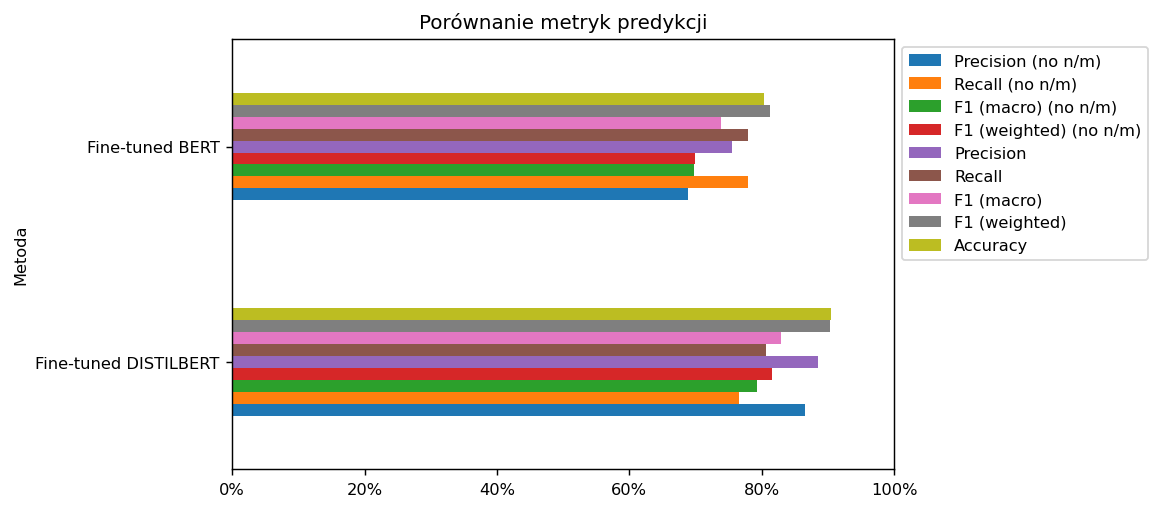

,Precision (no n/m),Recall (no n/m),F1 (macro) (no n/m),F1 (weighted) (no n/m),Precision,Recall,F1 (macro),F1 (weighted),Accuracy
Metoda,,,,,,,,,
Fine-tuned DISTILBERT,0.865,0.765,0.792,0.816,0.886,0.806,0.829,0.904,0.905
Fine-tuned BERT,0.688,0.779,0.698,0.700,0.755,0.779,0.738,0.813,0.804


In [9]:
rows = []
sentiment_no_notmentioned = [label for label in SENTIMENT_LABELS if label != "notmentioned"]

for name, p in preds.items():
    yt, yp = flat(gt), flat(p)
    rows.append({
        "Metoda": name,
        "Precision (no n/m)": precision_score(yt, yp, labels=sentiment_no_notmentioned, average="macro", zero_division=0),
        "Recall (no n/m)": recall_score(yt, yp, labels=sentiment_no_notmentioned, average="macro", zero_division=0),
        "F1 (macro) (no n/m)": f1_score(yt, yp, labels=sentiment_no_notmentioned, average="macro", zero_division=0),
        "F1 (weighted) (no n/m)": f1_score(yt, yp, labels=sentiment_no_notmentioned, average="weighted", zero_division=0),
        "Precision": precision_score(yt, yp, labels=SENTIMENT_LABELS, average="macro", zero_division=0),
        
        "Recall": recall_score(yt, yp, labels=SENTIMENT_LABELS, average="macro", zero_division=0),
        "F1 (macro)": f1_score(yt, yp, labels=SENTIMENT_LABELS, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(yt, yp, labels=SENTIMENT_LABELS, average="weighted", zero_division=0),
        
        "Accuracy": accuracy_score(yt, yp),
    })

perf = pd.DataFrame(rows).set_index("Metoda")

fig, ax = plt.subplots(figsize=(9, max(len(preds) * 2, 1)))

perf.plot.barh(ax=ax)

# Ustaiwienie żeby wyświetlało się 0% i 100%
ax.set_xlim(0, 1)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.set_title("Porównanie metryk predykcji")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")

plt.tight_layout()
plt.show()

perf.style.format("{:.3f}")

In [10]:
from sklearn.metrics import classification_report

print(classification_report(yt, yp, digits=3))

              precision    recall  f1-score   support

    negative      0.674     0.861     0.756        36
     neutral      0.842     0.516     0.640        31
notmentioned      0.957     0.778     0.858       482
    positive      0.549     0.959     0.698       123

    accuracy                          0.804       672
   macro avg      0.755     0.779     0.738       672
weighted avg      0.862     0.804     0.813       672



In [11]:
from sklearn.metrics import f1_score

# Define only the active sentiment labels
sentiment_labels = ["positive", "neutral", "negative"]

# Calculate Macro F1 strictly for sentiments
sentiment_f1 = f1_score(
    yt, yp, 
    labels=sentiment_labels, 
    average="macro", 
    zero_division=0
)

print(f"Sentiment-Only F1 (Macro): {sentiment_f1:.3f}")

Sentiment-Only F1 (Macro): 0.698


In [12]:
# Create binary lists: 1 if mentioned (pos/neg/neu), 0 if notmentioned
yt_binary = [0 if label == "notmentioned" else 1 for label in yt]
yp_binary = [0 if label == "notmentioned" else 1 for label in yp]

# Evaluate Aspect Detection
detection_f1 = f1_score(yt_binary, yp_binary, average="binary")
print(f"Aspect Detection F1: {detection_f1:.3f}")

Aspect Detection F1: 0.736


## 2. F1-score per aspekt
*cf. Table 6 — Gonçalves et al. (2013)*

F1 macro dla każdej kombinacji (metoda × aspekt) — pozwala zidentyfikować, które aspekty są najtrudniejsze dla poszczególnych metod.

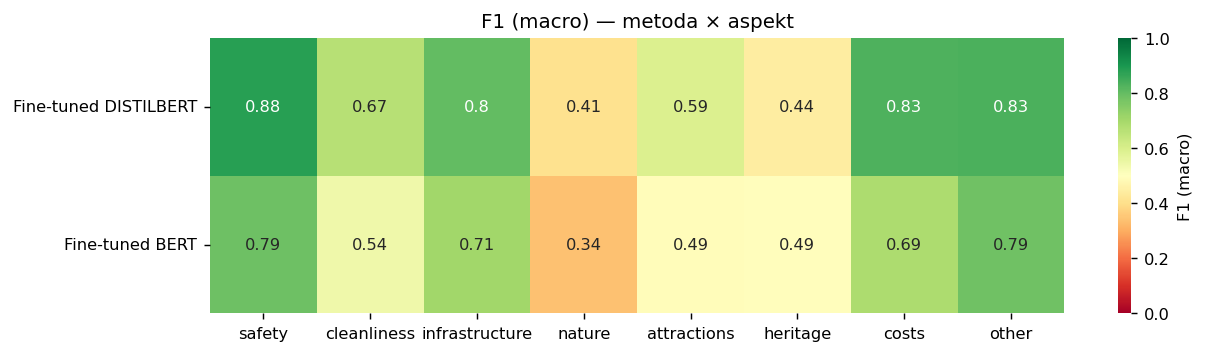

In [13]:
color_map = sns.color_palette("RdYlGn", as_cmap=True)

f1_asp = pd.DataFrame({
    name: {a: f1_score(gt[a], p[a], labels=SENTIMENT_LABELS, average="macro", zero_division=0) for a in ASPECTS}
    for name, p in preds.items()
}).T

fig, ax = plt.subplots(figsize=(10, max(len(preds) * 1.4, 2.5)))
sns.heatmap(
    f1_asp, annot=True, cmap=color_map, vmin=0, vmax=1, ax=ax, cbar_kws={"label": "F1 (macro)"},
)
ax.set_title("F1 (macro) — metoda × aspekt")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Agreement między metodami
*cf. Table 4 — Gonçalves et al. (2013)*

Odsetek par (recenzja × aspekt) dla których dwie metody przewidziały **identyczny** sentyment. Wysoka zgodność wzmacnia zaufanie do klasyfikacji; niska wskazuje, że metody interpretują tekst odmiennie.

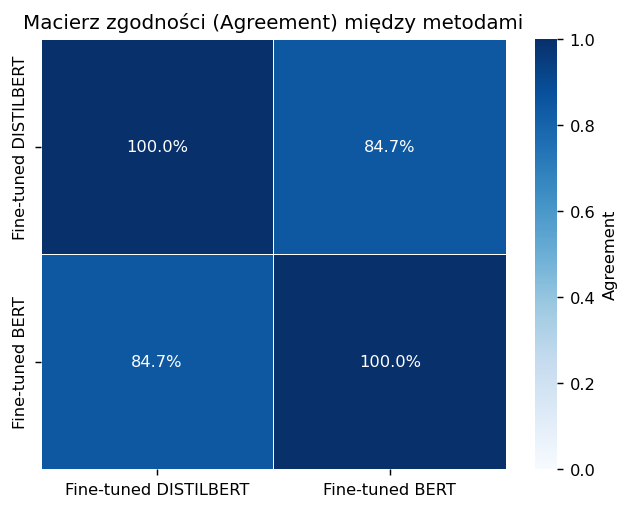

In [14]:
names = list(preds.keys())
agr = pd.DataFrame(
    [[(flat(preds[a]) == flat(preds[b])).mean() if i != j else 1.0
      for j, b in enumerate(names)]
     for i, a in enumerate(names)],
    index=names, columns=names,
)

fig, ax = plt.subplots(figsize=(max(len(names) * 2.5, 5), max(len(names) * 2, 4)))
sns.heatmap(
    agr, annot=True, fmt=".1%", cmap="Blues", vmin=0, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={"label": "Agreement"},
)
ax.set_title("Macierz zgodności (Agreement) między metodami")
plt.tight_layout()
plt.show()

## 4. Coverage
*cf. Figure 1 & Figure 4(a) — Gonçalves et al. (2013)*

Coverage = odsetek predykcji **różnych od `notmentioned`**. Niska wartość oznacza, że metoda nie wykrywa sentymentu i klasyfikuje większość par (recenzja × aspekt) jako niewspomniany. Jest to odpowiednik „fraction of messages whose sentiment is identified" z artykułu Gonçalves et al.

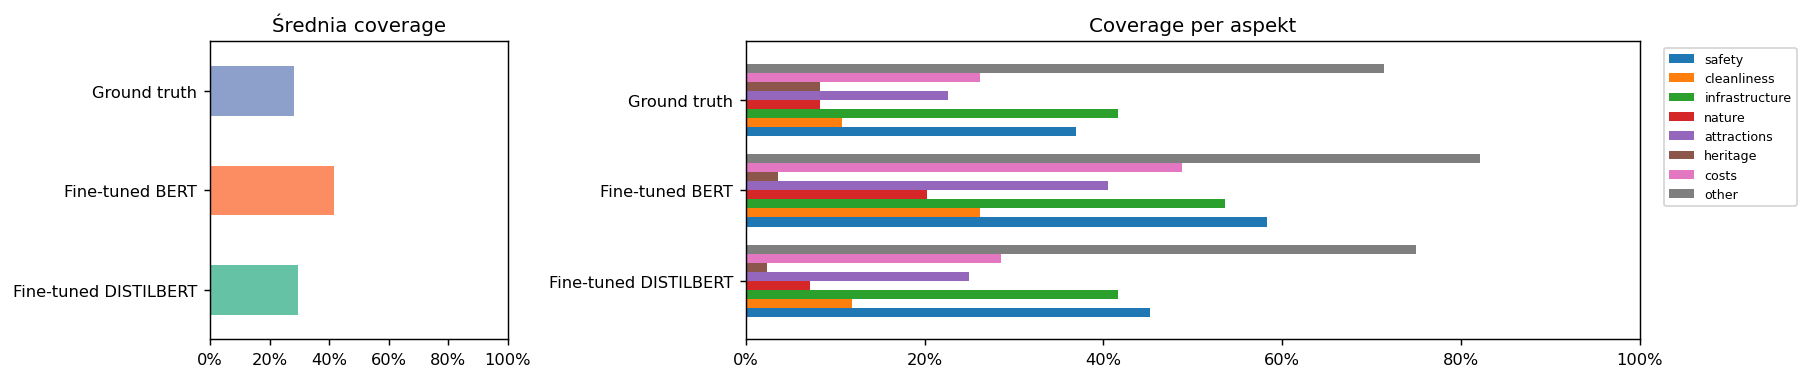

In [15]:
cov = pd.DataFrame(
    {n: {a: (p[a] != "notmentioned").mean() for a in ASPECTS} for n, p in preds.items()}
    | {"Ground truth": {a: (gt[a] != "notmentioned").mean() for a in ASPECTS}}
).T

fig, axes = plt.subplots(1, 2, figsize=(14, max(len(cov) * 1.0, 3)),
                          gridspec_kw={"width_ratios": [1, 3]})

cov.mean(axis=1).plot.barh(ax=axes[0], color=sns.color_palette("Set2", len(cov)))
axes[0].set_xlim(0, 1)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Średnia coverage")

cov.plot.barh(ax=axes[1], width=0.8)
axes[1].set_xlim(0, 1)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Coverage per aspekt")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

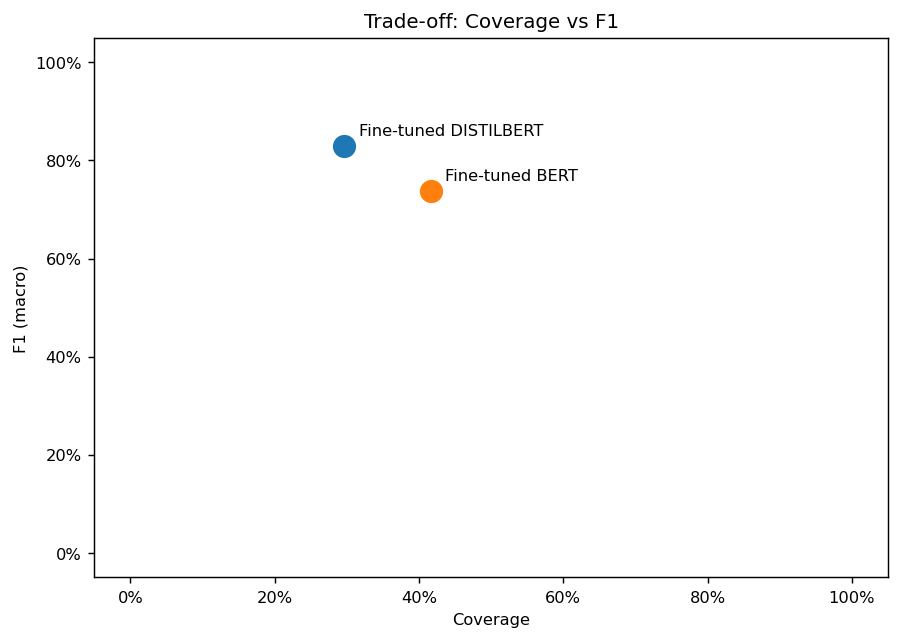

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
for name in preds:
    yt, yp = flat(gt), flat(preds[name])
    f1 = f1_score(yt, yp, labels=SENTIMENT_LABELS, average="macro", zero_division=0)
    c = (yp != "notmentioned").mean()
    ax.scatter(c, f1, s=140, zorder=5)
    ax.annotate(name, (c, f1), textcoords="offset points", xytext=(8, 6), fontsize=9)

ax.set_xlabel("Coverage")
ax.set_ylabel("F1 (macro)")

ax.set_title("Trade-off: Coverage vs F1")

# Pokazanie wykresu w zakresie 0-1 z 0.05 przesunięciem
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## 5. Macierze pomyłek (Confusion Matrices)

Macierz pomyłek dla każdej metody, zagregowana po wszystkich aspektach. Kolory odpowiadają proporcji wierszowej (recall per klasa), liczby to wartości bezwzględne.

In [17]:
# n_methods = len(preds)
# fig, axes = plt.subplots(1, n_methods, figsize=(5.5 * n_methods, 4.5))
# if n_methods == 1:
#     axes = [axes]

# short = ["pos", "neu", "neg", "n/m"]

# for ax, (name, p) in zip(axes, preds.items()):
#     yt, yp = flat(gt), flat(p)
#     cm = confusion_matrix(yt, yp, labels=SENTIMENT_LABELS)
#     row_sums = cm.sum(axis=1, keepdims=True)
#     row_sums[row_sums == 0] = 1
#     cm_norm = cm / row_sums

#     annot = np.array([
#         [f"{v}\n{pct:.0%}" for v, pct in zip(r, rn)]
#         for r, rn in zip(cm, cm_norm)
#     ])

#     sns.heatmap(
#         cm_norm, annot=annot, fmt="", cmap="Blues",
#         xticklabels=short, yticklabels=short,
#         ax=ax, vmin=0, vmax=1, cbar=False,
#     )
#     ax.set_title(name)
#     ax.set_ylabel("Ground truth" if ax is axes[0] else "")
#     ax.set_xlabel("Predykcja")

# plt.suptitle("Macierze pomyłek (wartości + % wiersza)", y=1.02, fontsize=12)
# plt.tight_layout()
# plt.show()